Poniższa funkcja, biorąc jako argumenty słownik z liczbą poszczególnych słów w danym tekście oraz liczbę najpopularniejszych słów w języku z częstotliwościami występowania ocenia, z jakim prawdopodobieństwem tekst został napisany w danym języku - im wyższy wynik, tym więcej słów z tekstu należy do słownika danego języka.

In [2]:
def lang_confidence_score(word_counts, language_words_with_frequency):
    # word_counts: słownik {slowo: liczba_wystapien_w_tekscie}
    # language_words_with_frequency: słownik {slowo: czestotliwosc_w_jezyku}

    total_words_in_text = sum(word_counts.values()) # liczba słów w tekście
    
    if total_words_in_text == 0 or not language_words_with_frequency:
        return 0.0

    matched_words_count = 0

    for word, count in word_counts.items():
        if word in language_words_with_frequency:
            # Słowo istnieje w języku - dodajemy jego wystąpienia do sumy
            matched_words_count += count
    
    return matched_words_count / total_words_in_text

Do analizy użyto pięciu tekstów:
1. Tekst z Bulbapedii o Pikachu (word-counts-wiki-good.json),
2. Tekst z Bulbapedii o Honor of Kalos (word-counts-wiki-bad.json),
3. Książka "One Flew Over The Cuckoo's Nest" Kena Keseya (PDF text-english.pdf oraz słownik word-counts-english-text),
4. Książka "Ostatnie życzenie" Andrzeja Sapkowskiego (PDF text-polish.pdf oraz słownik word-counts-polish-text),
5. Książka "La peste" Alberta Camusa (po polsku "Dżuma", PDF text-french.pdf oraz słownik word-counts-french-text).

Słowniki postaci {slowo: liczba_wystapien_w_tekscie} dla pierwszych dwóch tekstów zostały wyekstraktowane za pomocą programu wiki_scraper.py z argumentem --count-words, pozostałe za pomocą poniższego kodu:  

In [3]:
from collections import Counter
import json
import pdfplumber

# Funkcja zamieniająca plik PDF na tekst:
def pdf_to_text(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

# Funkcja tożsama z tą z programu wiki_scraper.py, która zlicza liczbę wystąpień poszczególnych słów w tekście text
# i zapisuje słownik do pliku filename:
def count_words(text, filename):
    # Podział na słowa, usuwanie znaków interpunkcyjnych:
    raw_words = text.split()
    clean_words = [] # lista słów

    for word in raw_words:
        # Usuwamy interpunkcję z początku i końca słowa
        word_stripped = word.strip('.,!?;:"()[]{}<>-\\/')
        if word_stripped:
            clean_words.append(word_stripped.lower())
        
    # Słownik ze słowami i z liczbą ich wystąpień:
    total_counts = Counter(clean_words)

    try:
        with open(filename, 'w') as f:
            json.dump(total_counts, f, ensure_ascii=False, indent=4)
        print(f"Successfully updated {filename}")
    except IOError as e:
        print(f"Error saving JSON: {e}")

# === Angielski tekst: ===
# Ken Kesey - "One Flew Over The Cuckoo’s Nest"
file_path_english = 'text-english.pdf'
text_english = pdf_to_text(file_path_english)
count_words(text_english, "word-counts-english-text.json")

# == Polski tekst: ===
# Andrzej Sapkowski - "Ostatnie życzenie"
file_path_polish = 'text-polish.pdf'
text_polish = pdf_to_text(file_path_polish)
count_words(text_polish, "word-counts-polish-text.json")

# == Francuski tekst: ==
# Albert Camus - "La Peste" ("Dżuma", francuski oryginał)
file_path_french = 'text-french.pdf'
text_french = pdf_to_text(file_path_french)
count_words(text_french, "word-counts-french-text.json")

Successfully updated word-counts-english-text.json
Successfully updated word-counts-polish-text.json
Successfully updated word-counts-french-text.json


Poniższy kod oblicza wartość funkcji lang_confidence_score dla każdego z trzech analizowanych języków i dla każdego z pięciu tekstów, a następnie tworzy wykresy przedstawiające wyniki według języka dla k = [3, 10, 100, 1000].

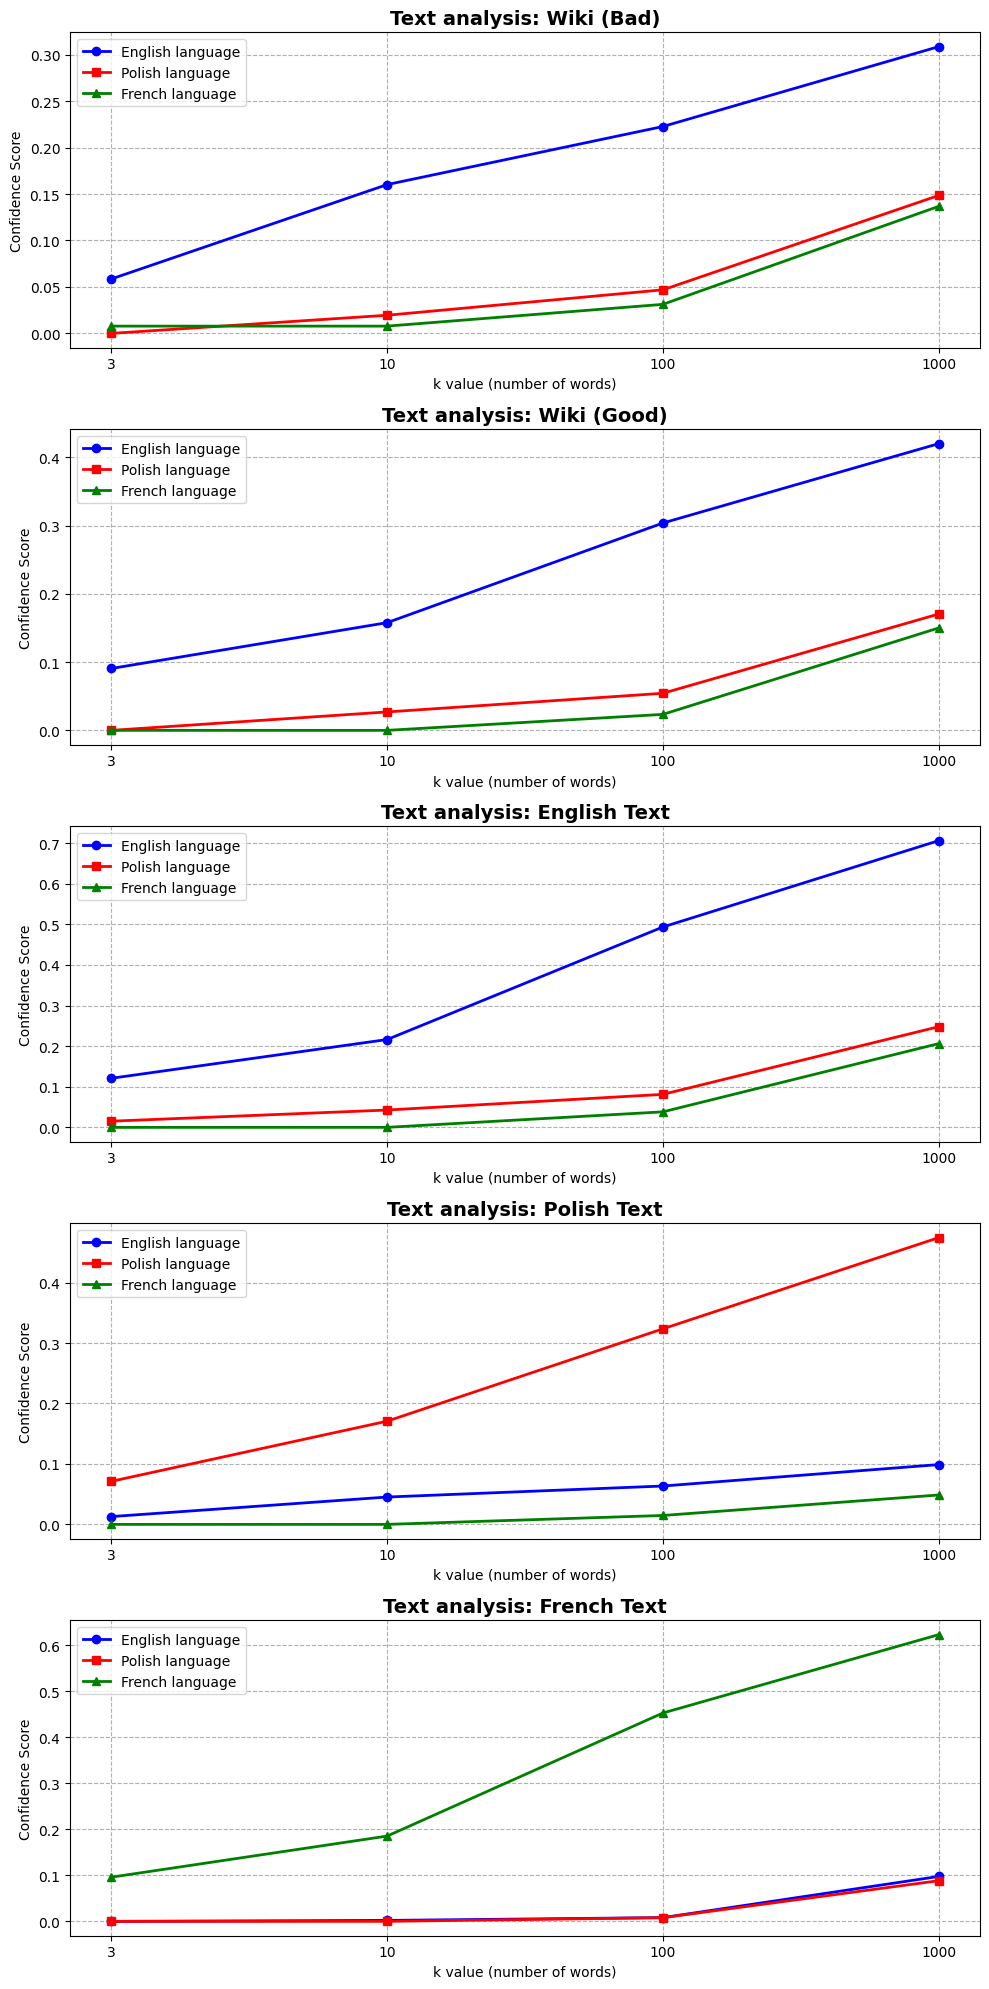

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from wordfreq import top_n_list, word_frequency

k = 1000

# Top k słów dla wybranych języków:
top_words_en = top_n_list('en', k) # język angielski
top_words_pl = top_n_list('pl', k) # język polski
top_words_fr = top_n_list('fr', k) # język francuski

results_data = [] 

file_labels = {
    "word-counts-wiki-bad.json": "Wiki (Bad)",
    "word-counts-wiki-good.json": "Wiki (Good)", 
    "word-counts-english-text.json": "English Text",
    "word-counts-polish-text.json": "Polish Text",
    "word-counts-french-text.json": "French Text"
}

texts = list(file_labels.keys()) # nazwy plików
k_values = [3, 10, 100, 1000]

for i in k_values:
    # Słowniki postaci (słowo: częstotliwość) dla wybranych języków: 
    lang_en = {w: word_frequency(w, 'en') for w in top_words_en[:i]}
    lang_pl = {w: word_frequency(w, 'pl') for w in top_words_pl[:i]}
    lang_fr = {w: word_frequency(w, 'fr') for w in top_words_fr[:i]}

    for filename in texts:
        try:
            with open(filename, 'r') as file_handle:
                word_counts = json.load(file_handle)
                # Obliczanie wyników:
                score_en = lang_confidence_score(word_counts, lang_en)
                score_pl = lang_confidence_score(word_counts, lang_pl)
                score_fr = lang_confidence_score(word_counts, lang_fr)
                # Zapis do listy
                results_data.append({
                    "k": str(i),
                    "Text": file_labels.get(filename, filename),
                    "English": score_en,
                    "Polish": score_pl,
                    "French": score_fr
                })
        except FileNotFoundError:
            print(f"File not found (skipped): {filename}")

# Tworzenie DataFrame
df = pd.DataFrame(results_data)

# Rysowanie wykresu:
unique_texts = df["Text"].unique() # Pobieramy unikalne nazwy tekstów

# Tworzymy osobny wykres dla każdego tekstu źródłowego
fig, axes = plt.subplots(nrows=len(unique_texts), ncols=1, figsize=(10, 4 * len(unique_texts)))
if len(unique_texts) == 1: axes = [axes] # Obsługa przypadku z 1 plikiem

for idx, text_name in enumerate(unique_texts): # idx - numer wykresu
    ax = axes[idx]
    subset = df[df["Text"] == text_name] # wiersze z df z przetwarzanym tekstem
    
    # Rysowanie linii dla każdego języka
    ax.plot(subset["k"], subset["English"], marker='o', label='English language', color='blue', linewidth=2)
    ax.plot(subset["k"], subset["Polish"], marker='s', label='Polish language', color='red', linewidth=2)
    ax.plot(subset["k"], subset["French"], marker='^', label='French language', color='green', linewidth=2)
    
    ax.set_title(f'Text analysis: {text_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Confidence Score')
    ax.set_xlabel('k value (number of words)')
    ax.legend()
    ax.grid(True, linestyle='--')


plt.tight_layout()
plt.savefig("text_analysis_results.png") # Zapis do pliku
plt.show()

=== OGÓLNE SPOSTRZEŻENIA ===

Zależność od parametru k:
- Na wszystkich wykresach widać wyraźną tendencję wzrostową: im większa wartość k (szersza lista najpopularniejszych słów brana pod uwagę), tym wyższy wynik Confidence Score. 
- Dla małych wartości k, różnice między językami są niewielkie, ale wyraźne. Dla k=1000 separacja właściwego języka od pozostałych jest bardzo widoczna.

Skuteczność detekcji:
Funkcja lang_confidence_score poprawnie identyfikuje język, w jakim został napisany tekst, nawet dla niskiego współczynnika k. Metoda działa dobrze zarówno dla długich tekstów jednojęzycznych, jak i krótszych artykułów z Bulbapedii - język angielski jest wykrywany poprawnie nawet dla artykułu z małą liczbą często używanych angielskich słów (wiki-bad).

Separacja języków:
- Dla tekstów w języku angielskim i francuskim (wykresy 3 i 5) maksymalne wyniki osiągają wysokie wartości (odpowiednio około 0.7 i 0.6), a pozostałe języki pozostają nisko.
- Dla tekstu polskiego (wykres 4) maksymalny wynik jest niższy (około 0.47), co sugeruje specyfikę języka, omówioną niżej.



=== ODPOWIEDZI NA PYTANIA ===

1. Czy dobór języka miał znaczenie?
Tak, dobór języka miał znaczenie - wybór języków z różnych grup lub o różnej specyfice gramatycznej ułatwia ich rozróżnienie. Język angielski, polski i francuski należą do różnych grup języków. Gdyby wybrane języki były ze sobą blisko spokrewnione, wykresy prawdopodobnie "zachodziłyby" na siebie znacznie bardziej, ponieważ blisko spokrewnione języki dzielą wiele wspólnych rdzeni słów lub identycznych spójników.

2. Czy po wartościach language_words_with_frequency widać, że w wybranym języku słowa często są odmieniane?
Tak, widać to wyraźnie na przykładzie języka polskiego. W języku polskim, w przeciwieństwie do angielskiego czy francuskiego, jedno słowo może wystąpić w tekście w wielu różnych formach (np. dwa - dwie, dwoje, dwóch, dwojga...). Jeśli w liście top_n_list znajduje się tylko forma podstawowa, to funkcja nie zliczy wystąpień słowa w innych przypadkach, przez co wynik lang_confidence_score jest niższy, niż w przypadku innych języków.

3. Czy trudne było znalezienie takiego artykułu, dla którego wynik language_words_with_frequency jest jak najmniejszy w języku wiki? Czy to jest specyfika tego wiki?
Tak, znalezienie takiego artykułu było trudne - nawet dla artykułów zawierających niewiele słów z języka wiki i z wieloma nazwami własnymi, najpopularniejsze słowa z języka wiki nadal często się w nich pojawiają, a już przedimek "the" oraz słowa "is" lub "are", będące jednymi z najpopularniejszych w angielskich, pojawiają się w praktycznie każdym artykule na samym jego początku, przez co zdradzają język, w jakim został napisany. 
Nie jest to specyfika tego konkretnego Wiki - artykuły na większości Wiki są pisane standardowym, poprawnym gramatycznie językiem, który z natury jest nasycony najpopularniejszymi słowami w języku. Na początku każdego artykułu, nie tylko na Bulbapedii, często znajduje się krótki wstęp na temat omawianej rzeczy, który często zawiera najpopularniejsze słowa w języku: przedimki przez rzeczownikami, odmiana słowa "jest", a także popularne zaimki czy spójniki.